# Real CCF Prediction and `vrad` Range Scan

This notebook combines the current workflow into one place:

1. Generate iCCF CCFs from S1D spectra for a chosen `vrad_min` and `vrad_max`
2. Normalize the CCFs exactly as in `predict_real_ccf_mlp_notebook.ipynb`
3. Predict RVs with the saved MLP model and compare them with iCCF RVs
4. Loop over a range of `vrad_min` values, using `vrad_max = vrad_min + 30`, and collect the statistics in one dataframe


In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow import keras
from tqdm.auto import tqdm

from generate_real_s1d_iccf_dataset import generate_real_s1d_iccf_dataframe


2026-04-14 16:02:39.412509: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 16:02:39.434743: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776178959.460117  114177 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776178959.467895  114177 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776178959.487704  114177 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
INPUT_DIR = Path("./S1D_spectra/")
MODEL_DIR = Path("./mlp_full_model_526_256_128_64_32")
OUTPUT_DIR = Path("./vrad_scan_outputs")

MASK_NAME = "G2"
MASK_INSTRUMENT = "ESPRESSO"
MASK_WIDTH = 0.5
VRAD_STEP = 0.1
WINDOW_SIZE = 30.0

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert INPUT_DIR.exists(), f"Missing input directory: {INPUT_DIR}"
assert MODEL_DIR.exists(), f"Missing model directory: {MODEL_DIR}"

print("Input dir:", INPUT_DIR)
print("Model dir:", MODEL_DIR)
print("Output dir:", OUTPUT_DIR)


Input dir: S1D_spectra
Model dir: mlp_full_model_526_256_128_64_32
Output dir: vrad_scan_outputs


In [3]:
def load_model_bundle(model_dir: str | Path) -> dict:
    model_dir = Path(model_dir)
    metadata = json.loads((model_dir / "preprocessing_metadata.json").read_text())
    artifacts = np.load(model_dir / "preprocessing_artifacts.npz", allow_pickle=False)
    model = keras.models.load_model(model_dir / "rv_model.keras")
    return {
        "model": model,
        "metadata": metadata,
        "ccf_columns": metadata["ccf_columns"],
        "x_mean": artifacts["x_mean"].astype(np.float32),
        "x_scale": artifacts["x_scale"].astype(np.float32),
        "y_mean": artifacts["y_mean"].astype(np.float32),
        "y_scale": artifacts["y_scale"].astype(np.float32),
    }


def generate_ccf_dataframe(
    *,
    input_dir: str | Path,
    vrad_min: float,
    vrad_max: float,
    vrad_step: float = 0.1,
    recursive: bool = False,
    pattern: str = "*.fits",
    mask_name: str = "G2",
    mask_instrument: str = "ESPRESSO",
    mask_width: float = 0.5,
    show_progress: bool = True,
) -> pd.DataFrame:
    return generate_real_s1d_iccf_dataframe(
        input_dir=input_dir,
        recursive=recursive,
        pattern=pattern,
        mask_name=mask_name,
        mask_instrument=mask_instrument,
        mask_width=mask_width,
        vrad_min=vrad_min,
        vrad_max=vrad_max,
        vrad_step=vrad_step,
        show_progress=show_progress,
    )


def normalize_ccf_for_model(ccf_df: pd.DataFrame, ccf_columns: list[str]) -> pd.DataFrame:
    missing = [col for col in ccf_columns if col not in ccf_df.columns]
    if missing:
        raise ValueError(f"Missing {len(missing)} expected CCF columns. First missing: {missing[:5]}")

    normalized_df = ccf_df[ccf_columns].copy()
    row_max = normalized_df.max(axis=1)
    if (row_max == 0).any():
        raise ValueError("At least one CCF row has max=0, so row-wise normalization would fail.")

    normalized_df[ccf_columns] = normalized_df[ccf_columns].div(row_max, axis=0)
    normalized_df[ccf_columns] = normalized_df[ccf_columns].round(4)
    return normalized_df


def predict_rvs_from_normalized_ccf(normalized_df: pd.DataFrame, bundle: dict) -> pd.DataFrame:
    ccf_columns = bundle["ccf_columns"]
    X = normalized_df[ccf_columns].to_numpy(dtype=np.float32)
    X_scaled = ((X - bundle["x_mean"]) / bundle["x_scale"]).astype(np.float32)

    y_pred_scaled = bundle["model"].predict(X_scaled, verbose=0).reshape(-1)
    y_pred = y_pred_scaled * bundle["y_scale"][0] + bundle["y_mean"][0]

    return pd.DataFrame({"predicted_rv_mps": y_pred.astype(np.float64)})


def compare_predicted_and_true(
    ccf_df: pd.DataFrame,
    prediction_df: pd.DataFrame,
    *,
    center_series: bool = True,
    make_plot: bool = True,
) -> tuple[pd.DataFrame, dict]:
    comparison_df = pd.DataFrame({
        "rv_iccf_mps": ccf_df["rv_iccf_mps"].to_numpy(dtype=float),
        "predicted_rv_mps": prediction_df["predicted_rv_mps"].to_numpy(dtype=float),
    })

    if center_series:
        comparison_df["rv_iccf_mps_used"] = comparison_df["rv_iccf_mps"] - comparison_df["rv_iccf_mps"].mean()
        comparison_df["predicted_rv_mps_used"] = comparison_df["predicted_rv_mps"] - comparison_df["predicted_rv_mps"].mean()
    else:
        comparison_df["rv_iccf_mps_used"] = comparison_df["rv_iccf_mps"]
        comparison_df["predicted_rv_mps_used"] = comparison_df["predicted_rv_mps"]

    comparison_df["residual_mps"] = comparison_df["predicted_rv_mps_used"] - comparison_df["rv_iccf_mps_used"]
    residual = comparison_df["residual_mps"].to_numpy(dtype=float)

    stats = {
        "n_samples": int(len(comparison_df)),
        "true_mean_mps": float(comparison_df["rv_iccf_mps_used"].mean()),
        "pred_mean_mps": float(comparison_df["predicted_rv_mps_used"].mean()),
        "bias_mps": float(np.mean(residual)),
        "std_mps": float(np.std(residual, ddof=1)) if len(residual) > 1 else np.nan,
        "mae_mps": float(np.mean(np.abs(residual))),
        "median_abs_err_mps": float(np.median(np.abs(residual))),
        "rmse_mps": float(np.sqrt(np.mean(residual ** 2))),
        "min_residual_mps": float(np.min(residual)),
        "max_residual_mps": float(np.max(residual)),
        "pearson_r": float(
            np.corrcoef(
                comparison_df["rv_iccf_mps_used"].to_numpy(dtype=float),
                comparison_df["predicted_rv_mps_used"].to_numpy(dtype=float),
            )[0, 1]
        ) if len(comparison_df) > 1 else np.nan,
    }

    if make_plot:
        plt.figure(figsize=(6, 6))
        plt.scatter(
            comparison_df["rv_iccf_mps_used"],
            comparison_df["predicted_rv_mps_used"],
            alpha=0.8,
        )
        min_val = min(comparison_df["rv_iccf_mps_used"].min(), comparison_df["predicted_rv_mps_used"].min())
        max_val = max(comparison_df["rv_iccf_mps_used"].max(), comparison_df["predicted_rv_mps_used"].max())
        plt.plot([min_val, max_val], [min_val, max_val], "k--", linewidth=1)
        plt.xlabel("True RV [m/s]")
        plt.ylabel("Predicted RV [m/s]")
        plt.title("Predicted vs true RV")
        plt.grid(alpha=0.3)
        plt.show()

    return comparison_df, stats


def run_single_vrad_case(
    *,
    bundle: dict,
    input_dir: str | Path,
    vrad_min: float,
    vrad_max: float,
    vrad_step: float = 0.1,
    recursive: bool = False,
    pattern: str = "*.fits",
    mask_name: str = "G2",
    mask_instrument: str = "ESPRESSO",
    mask_width: float = 0.5,
    center_series: bool = True,
    make_plot: bool = True,
    save_prefix: str | Path | None = None,
) -> dict:
    ccf_df = generate_ccf_dataframe(
        input_dir=input_dir,
        vrad_min=vrad_min,
        vrad_max=vrad_max,
        vrad_step=vrad_step,
        recursive=recursive,
        pattern=pattern,
        mask_name=mask_name,
        mask_instrument=mask_instrument,
        mask_width=mask_width,
        show_progress=True,
    )

    normalized_df = normalize_ccf_for_model(ccf_df, bundle["ccf_columns"])
    prediction_df = predict_rvs_from_normalized_ccf(normalized_df, bundle)
    comparison_df, stats = compare_predicted_and_true(
        ccf_df,
        prediction_df,
        center_series=center_series,
        make_plot=make_plot,
    )

    stats = {
        "vrad_min": float(vrad_min),
        "vrad_max": float(vrad_max),
        "vrad_step": float(vrad_step),
        **stats,
    }

    if save_prefix is not None:
        save_prefix = Path(save_prefix)
        save_prefix.parent.mkdir(parents=True, exist_ok=True)
        ccf_df.to_csv(save_prefix.with_name(save_prefix.name + "_ccf.csv"), index=False)
        normalized_df.to_csv(save_prefix.with_name(save_prefix.name + "_normalized.csv"), index=False)
        prediction_df.to_csv(save_prefix.with_name(save_prefix.name + "_predictions.csv"), index=False)
        comparison_df.to_csv(save_prefix.with_name(save_prefix.name + "_comparison.csv"), index=False)

    return {
        "ccf_df": ccf_df,
        "normalized_df": normalized_df,
        "prediction_df": prediction_df,
        "comparison_df": comparison_df,
        "stats": stats,
    }


def scan_vrad_ranges(
    *,
    bundle: dict,
    input_dir: str | Path,
    vrad_min_values: Iterable[float],
    window_size: float = 30.0,
    vrad_step: float = 0.1,
    recursive: bool = False,
    pattern: str = "*.fits",
    mask_name: str = "G2",
    mask_instrument: str = "ESPRESSO",
    mask_width: float = 0.5,
    center_series: bool = True,
    save_stats_path: str | Path | None = None,
) -> pd.DataFrame:
    rows = []
    iterator = list(vrad_min_values)

    for vrad_min in tqdm(iterator, desc="Scanning vrad ranges", unit="range"):
        vrad_max = float(vrad_min + window_size)
        result = run_single_vrad_case(
            bundle=bundle,
            input_dir=input_dir,
            vrad_min=float(vrad_min),
            vrad_max=vrad_max,
            vrad_step=vrad_step,
            recursive=recursive,
            pattern=pattern,
            mask_name=mask_name,
            mask_instrument=mask_instrument,
            mask_width=mask_width,
            center_series=center_series,
            make_plot=False,
            save_prefix=None,
        )
        rows.append(result["stats"])

    stats_df = pd.DataFrame(rows).sort_values("vrad_min").reset_index(drop=True)

    if save_stats_path is not None:
        save_stats_path = Path(save_stats_path)
        save_stats_path.parent.mkdir(parents=True, exist_ok=True)
        stats_df.to_csv(save_stats_path, index=False)

    return stats_df


In [4]:
bundle = load_model_bundle(MODEL_DIR)
print("Expected number of CCF columns:", len(bundle["ccf_columns"]))
print("First column:", bundle["ccf_columns"][0])
print("Last column:", bundle["ccf_columns"][-1])


2026-04-14 16:02:42.386446: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Expected number of CCF columns: 301
First column: ccf_0000
Last column: ccf_0300


## Single `vrad` run

Set one `vrad_min` and `vrad_max`, then generate CCFs, normalize, predict, compare, and optionally save the intermediate tables.


S1D -> iCCF:   0%|          | 0/3 [00:00<?, ?file/s]

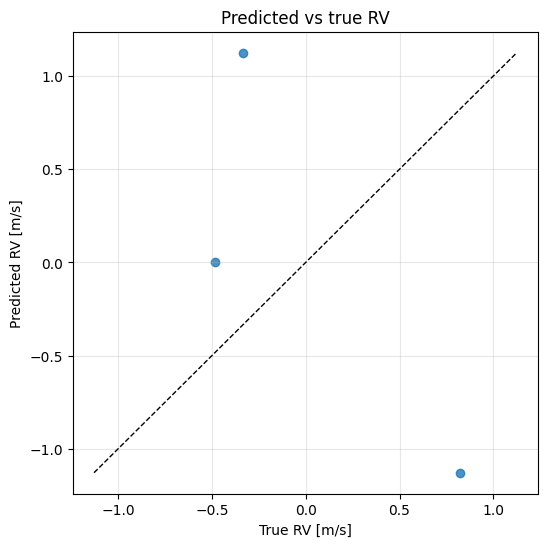

vrad_min             -32.000000
vrad_max               2.000000
vrad_step              0.100000
n_samples              3.000000
true_mean_mps          0.000000
pred_mean_mps          0.000000
bias_mps               0.000000
std_mps                1.758236
mae_mps                1.300690
median_abs_err_mps     1.461822
rmse_mps               1.435594
min_residual_mps      -1.951035
max_residual_mps       1.461822
pearson_r             -0.810742
dtype: float64

In [32]:
single_result = run_single_vrad_case(
    bundle=bundle,
    input_dir=INPUT_DIR,
    vrad_min=-32,
    vrad_max=2,
    vrad_step=VRAD_STEP,
    recursive=False,
    pattern="*.fits",
    mask_name=MASK_NAME,
    mask_instrument=MASK_INSTRUMENT,
    mask_width=MASK_WIDTH,
    center_series=True,
    make_plot=True,
    save_prefix=OUTPUT_DIR / "single_run",
)

pd.Series(single_result["stats"])


In [31]:
single_result["comparison_df"].head()


,rv_iccf_mps,predicted_rv_mps,rv_iccf_mps_used,predicted_rv_mps_used,residual_mps
0,-1020.031531,566.786560,-1.516153,-6.027991,-4.511838
1,-1019.911759,566.363037,-1.396381,-6.451514,-5.055132
2,-1014.859320,587.775208,3.656057,14.960657,11.304599
3,-1020.635748,568.018066,-2.120370,-4.796484,-2.676115
4,-1017.138531,575.129883,1.376846,2.315332,0.938486


## Scan a range of `vrad_min`

This loop always uses `vrad_max = vrad_min + 30` and stores one statistics row per tested range.


In [37]:
vrad_min_values = np.arange(-16.5, -15.5 + 0.001, 0.01)

scan_stats_df = scan_vrad_ranges(
    bundle=bundle,
    input_dir=INPUT_DIR,
    vrad_min_values=vrad_min_values,
    window_size=WINDOW_SIZE,
    vrad_step=VRAD_STEP,
    recursive=False,
    pattern="*.fits",
    mask_name=MASK_NAME,
    mask_instrument=MASK_INSTRUMENT,
    mask_width=MASK_WIDTH,
    center_series=True,
    save_stats_path=OUTPUT_DIR / "vrad_scan_stats.csv",
)

scan_stats_df


Scanning vrad ranges:   0%|          | 0/101 [00:00<?, ?range/s]

S1D -> iCCF:   0%|          | 0/30 [00:00<?, ?file/s]

S1D -> iCCF:   0%|          | 0/30 [00:00<?, ?file/s]

S1D -> iCCF:   0%|          | 0/30 [00:00<?, ?file/s]

S1D -> iCCF:   0%|          | 0/30 [00:00<?, ?file/s]

...

S1D -> iCCF:   0%|          | 0/30 [00:00<?, ?file/s]

S1D -> iCCF:   0%|          | 0/30 [00:00<?, ?file/s]

S1D -> iCCF:   0%|          | 0/30 [00:00<?, ?file/s]

S1D -> iCCF:   0%|          | 0/30 [00:00<?, ?file/s]

,vrad_min,vrad_max,vrad_step,n_samples,true_mean_mps,pred_mean_mps,bias_mps,std_mps,mae_mps,median_abs_err_mps,rmse_mps,min_residual_mps,max_residual_mps,pearson_r
0,-16.50,13.50,0.1,30,-3.031649e-14,-4.547474e-14,-1.515825e-14,16.162961,13.716493,13.917377,15.891295,-22.513139,33.111325,0.770760
1,-16.49,13.51,0.1,30,7.579123e-14,4.547474e-14,-3.031649e-14,14.869356,12.973598,12.673620,14.619433,-20.076367,28.375606,0.784500
2,-16.48,13.52,0.1,30,-1.136868e-14,-5.305386e-14,-4.168517e-14,13.101567,11.420522,11.258439,12.881357,-17.291750,24.942311,0.799498
3,-16.47,13.53,0.1,30,7.958079e-14,0.000000e+00,-7.958079e-14,10.725072,9.300411,8.852762,10.544806,-14.960147,18.889362,0.822637
4,-16.46,13.54,0.1,30,1.061077e-13,-3.789561e-14,-1.440033e-13,8.998969,7.616805,6.866424,8.847715,-13.050226,18.637228,0.835138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,-15.54,14.46,0.1,30,-6.063298e-14,-2.273737e-14,3.789561e-14,4.299998,3.357736,3.167751,4.227724,-6.684835,9.656792,0.725753
97,-15.53,14.47,0.1,30,2.349528e-13,3.789561e-15,-2.311632e-13,4.163858,3.262096,3.426713,4.093872,-6.913295,9.812354,0.717178
98,-15.52,14.48,0.1,30,-3.789561e-15,1.136868e-14,1.515825e-14,4.104239,3.133812,2.763978,4.035255,-6.762007,10.115805,0.694209
99,-15.51,14.49,0.1,30,2.652693e-14,-1.894781e-14,-4.547474e-14,4.038678,3.127475,2.857516,3.970796,-6.452962,10.381691,0.668715


In [44]:
scan_stats_df.head(2)

,vrad_min,vrad_max,vrad_step,n_samples,true_mean_mps,pred_mean_mps,bias_mps,std_mps,mae_mps,median_abs_err_mps,rmse_mps,min_residual_mps,max_residual_mps,pearson_r
0,-16.50,13.50,0.1,30,-3.031649e-14,-4.547474e-14,-1.515825e-14,16.162961,13.716493,13.917377,15.891295,-22.513139,33.111325,0.77076
1,-16.49,13.51,0.1,30,7.579123e-14,4.547474e-14,-3.031649e-14,14.869356,12.973598,12.673620,14.619433,-20.076367,28.375606,0.78450


In [41]:
scan_stats_df.sort_values("pearson_r").head(2)


,vrad_min,vrad_max,vrad_step,n_samples,true_mean_mps,pred_mean_mps,bias_mps,std_mps,mae_mps,median_abs_err_mps,rmse_mps,min_residual_mps,max_residual_mps,pearson_r
80,-15.70,14.30,0.1,30,-5.305386e-14,3.789561e-15,5.684342e-14,7.119858,5.471222,4.905726,7.000188,-14.836567,14.085651,0.210992
81,-15.69,14.31,0.1,30,-1.212660e-13,1.136868e-14,1.326346e-13,6.948719,5.173373,4.470577,6.831925,-14.558032,15.274678,0.213173


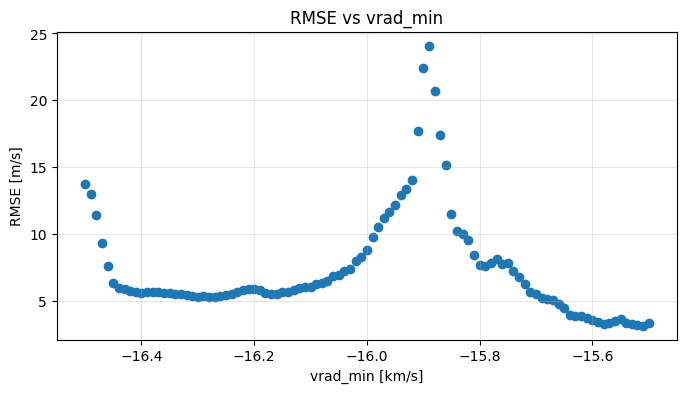

In [59]:
plt.figure(figsize=(8, 4))
plt.scatter(scan_stats_df["vrad_min"], scan_stats_df["mae_mps"], marker="o")
plt.xlabel("vrad_min [km/s]")
plt.ylabel("RMSE [m/s]")
plt.title("RMSE vs vrad_min")
plt.grid(alpha=0.3)
plt.show()
